# Clustering Semantico dei Report di Insicurezza Alimentare (IPC)

Questo notebook implementa una pipeline avanzata per il caricamento, la pulizia, l'embedding denso e il clustering semantico dei report IPC.  
L'obiettivo è raggruppare le situazioni di crisi in base alla tipologia di insicurezza alimentare e ai driver che le causano (es. conflitti, siccità, crisi economiche), indipendentemente dal paese.

La pipeline è strutturata nel seguente modo:
1. Setup dell'ambiente (installazione delle librerie necessarie).
2. Caricamento dei report anonimizzati.
3. Generazione di embedding con **bge-m3** (`BAAI/bge-m3`)
4. Riduzione dimensionale con **UMAP** (5D per clustering, 2D per visualizzazione).
5. Clustering con **K-Means** (e scelta ottimale di K con metriche geometriche come *Silhouette Score* e *Davies-Bouldin Index*) e **HDBSCAN**.
6. **Validazione della Coerenza Semantica**:
   - **Tabella di Contingenza** (Paese vs. Cluster) ed entropia geografica per escludere il bias geografico.
   - **Topic modeling** con c-TF-IDF (Class-based Term Frequency-Inverse Document Frequency)
   - **LLM-as-a-Judge**  per descrivere i cluster e valutarne la coerenza semantica.
7. Varie visualizzazioni interattive per mostrare l'evoluzione dei cluster.

## 1. Setup dell'Ambiente e caricamento testi anonimizzati

In [34]:
import pandas as pd
df = pd.read_csv("data/report_anonimizzati_ok.csv")
df

,Unnamed: 0,nome_file,paese,periodo,inizio_periodo,fine_periodo,testo_originale,report_anonimo
0,0,Gaza_Strip_Sep_2024_-_Apr_2025_KeyResults.txt,Gaza Strip,Sep 2024 / Apr 2025,Sep 2024,Apr 2025,"One year into the conflict, the risk of Famine...","One year into the conflict, the risk of Famine..."
1,1,Afghanistan_Apr_2020_-_Nov_2020_KeyResults.txt,Afghanistan,Apr 2020 / Nov 2020,Apr 2020,Nov 2020,Food insecurity remains alarmingly high in Afg...,Food insecurity remains alarmingly high in [AF...
2,2,Afghanistan_Nov_2017_-_Feb_2018_KeyResults.txt,Afghanistan,Nov 2017 / Feb 2018,Nov 2017,Feb 2018,"During the 2017 post-harvest season, 33% of th...","During the [DATE] post-harvest season, 33% of ..."
3,3,South_Sudan_Sep_2018_-_Mar_2019_KeyResults.txt,South Sudan,Sep 2018 / Mar 2019,Sep 2018,Mar 2019,"Based on the September IPC analysis, it is exp...","Based on the September IPC analysis, it is exp..."
4,4,Mozambique_Jun_2020_-_Sep_2020_KeyResults.txt,Mozambique,Jun 2020 / Sep 2020,Jun 2020,Sep 2020,The results of this Acute Food Insecurity pilo...,The results of this Acute Food Insecurity pilo...
...,...,...,...,...,...,...,...,...
492,492,Haiti_Aug_2023_-_Jun_2024_KeyResults.txt,Haiti,Aug 2023 / Jun 2024,Aug 2023,Jun 2024,About 4.35 million people are experiencing hig...,About 4.35 million people are experiencing hig...
493,493,Djibouti_Mar_2022_-_Dec_2022_KeyResults.txt,Djibouti,Mar 2022 / Dec 2022,Mar 2022,Dec 2022,For the current analysis period of March throu...,For the current analysis period of March throu...
494,494,Djibouti_May_2013_-_May_2013_KeyResults.txt,Djibouti,May 2013 / May 2013,May 2013,May 2013,Food availability in the Republic of Djibouti ...,Food availability in the [AFFECTED_AREA] is ma...
495,495,Madagascar_Sep_2024_-_Aug_2025_KeyResults.txt,Madagascar,Sep 2024 / Aug 2025,Sep 2024,Aug 2025,"Between September and December 2024, around 1....","Between September and December [DATE], around ..."


In [35]:
# 1.1 Monta Google Drive per accedere ai file dei report
#from google.colab import drive
import os
import pandas as pd
#drive.mount('/content/drive')

# Definisci il percorso della cartella contenente i report in formato .txt
# Modifica questo percorso se la tua cartella si trova altrove su Drive
DRIVE_PATH = "./"
#
TESTO_DIR = df["report_anonimo"]
#
#print(f"Directory dei report impostata su: {TESTO_DIR}")
#if os.path.exists(TESTO_DIR):
#    print(f"Trovati {len(os.listdir(TESTO_DIR))} elementi nella cartella.")
#else:
#    print("ATTENZIONE: Il percorso specificato non esiste. Verifica che Google Drive sia montato correttamente.")

In [3]:
# 1.3 Import delle librerie necessarie
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import pairwise_distances_argmin_min
import plotly.express as px
import torch
import scipy.stats as stats
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Impostiamo il seed per la riproducibilità dei risultati
np.random.seed(42)

# Download delle risorse NLTK per la lemmatizzazione
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet = True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)
print("NLTK e librerie importate correttamente.")

NLTK e librerie importate correttamente.


## 3. Generazione degli Embedding 

Utilizziamo il modello **`BAAI/bge-m3`** (Beijing Academy of Artificial Intelligence) per trasformare i report in vettori numerici ad alta densità (1024 dimensioni). Questo modello è stato selezionato per tre caratteristiche fondamentali per la nostra analisi dei driver di insicurezza climatica e alimentare:
-Finestra di contesto nativa a 8192 token: Consente di elaborare la lunghezza media dei nostri report (~1500 token) in un unico blocco. Questo evita la frammentazione del testo (chunking) e preserva le relazioni di causa-effetto strutturate lungo l'intero documento.
-Rappresentazione semantica densa: Cattura il significato profondo dei concetti e dei sinonimi tecnici. Riconosce che espressioni come "stress idrico prolungato" e "deficit pluviometrico" afferiscono alla stessa dinamica di fondo.
-Allineamento lessicale specialistico: Grazie alla sua architettura di recupero ibrida, mantiene un peso rigoroso sulle parole chiave tecniche, i codici IPC e gli indicatori geopolitici o agronomici specifici.

In [4]:
#l'embedder non ha componenti stocastiche

import os
import torch
import numpy as np
import pandas as pd
import re
from sentence_transformers import SentenceTransformer

# =====================================================================
# 1. FUNZIONE DI PULIZIA PREVENTIVA DEI TAG
# =====================================================================
def pulisci_testo_per_embedding(text: str) -> str:
    """
    Sostituisce i tag d'anonimizzazione con termini generici in minuscolo
    per mantenere la sintassi fluida ed evitare distorsioni nei vettori BGE-M3.
    """
    if not isinstance(text, str):
        return ""

    replacements = {
        r'\[AFFECTED_AREA\]': 'area',
        r'\[DATE\]': 'period',
        r'\[[A-Z_]+\]': ''  # Fallback per qualsiasi altro tag rimasto
    }

    clean_text = text
    for pattern, replacement in replacements.items():
        clean_text = re.sub(pattern, replacement, clean_text)

    return re.sub(r'\s+', ' ', clean_text).strip()


# =====================================================================
# 2. CARICAMENTO DEL NUOVO MODELLO BGE-M3
# =====================================================================
MODEL_NAME = "BAAI/bge-m3"

# Rilevamento corretto dell'acceleratore Apple Silicon (Metal Performance Shaders)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Caricamento modello {MODEL_NAME} su dispositivo: {device}...")

# Inizializzazione del modello BGE-M3
model = SentenceTransformer(
    MODEL_NAME,
    device=device,
    trust_remote_code=True,
)

# =====================================================================
# 3. PREPARAZIONE TESTI ED ESECUZIONE EMBEDDING
# =====================================================================
print("Preparazione e pulizia dei testi per BGE-M3...")
# Applichiamo la pulizia dei tag direttamente sulla colonna 'report_anonimo'
testi_puliti = [pulisci_testo_per_embedding(t) for t in df["report_anonimo"]]

print("Generazione degli embedding con BGE-M3 in corso...")
# BGE-M3 genera vettori normalizzati a 1024 dimensioni
embeddings = model.encode(
    testi_puliti,
    normalize_embeddings=True,
    show_progress_bar=True
)

print(f"Embedding generati con successo! Shape: {embeddings.shape}")

# =====================================================================
# 4. SALVATAGGIO DEI RISULTATI
# =====================================================================
# Assicurati che DRIVE_PATH sia definito nel tuo script (es. DRIVE_PATH = "./dati")
os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(os.path.join(DRIVE_PATH, "data"), exist_ok=True)

np.save(os.path.join(DRIVE_PATH, "embeddings_report_anonimi.npy"), embeddings)
df.to_parquet(os.path.join(DRIVE_PATH, "data/metadata_report_anonimi.parquet"))

print("Embedding BGE-M3 e metadati salvati correttamente!")

'\ndef estrai_metadata(nome_file):\n    base = nome_file.replace("_KeyResults.txt", "")\n\n    # Cerca il pattern del periodo: Mese_Anno_-_Mese_Anno (es. Apr_2016_-_Dec_2016)\n    periodo_match = re.search(r\'([A-Za-z]{3}_\\d{4})_-_([A-Za-z]{3}_\\d{4})\', base)\n\n    if periodo_match:\n        inizio_periodo = periodo_match.group(1).replace(\'_\', \' \')  # es. "Apr 2016"\n        fine_periodo = periodo_match.group(2).replace(\'_\', \' \')    # es. "Dec 2016"\n        periodo = f"{inizio_periodo} / {fine_periodo}"\n    else:\n        inizio_periodo = None\n        fine_periodo = None\n        periodo = base.replace(\'_\', \' \')\n\n    # Paese: tutto quello che precede il primo mese o anno\n    paese_match = re.match(r\'^(.+?)_[A-Za-z]{3}_\\d{4}\', base)\n    paese = paese_match.group(1).replace(\'_\', \' \') if paese_match else base.replace(\'_\', \' \')\n\n    return {\n        "paese": paese,\n        "periodo": periodo,\n        "inizio_periodo": inizio_periodo,\n        "fine_per

## 4. Riduzione Dimensionale con UMAP

Riduciamo la dimensionalità degli embedding tramite UMAP:
- A **5 dimensioni** per ottimizzare l'esecuzione del clustering (evitando il problema delle distanze geometriche in alte dimensioni).
- A **2 dimensioni** solo per la successiva rappresentazione grafica sul piano cartesiano.

In [5]:
# 4.1 Riduzione dimensionale con UMAP
print("UMAP a 5 dimensioni per il clustering...")
reducer_clustering = umap.UMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=5,
    metric="cosine",
    random_state=42
)
embeddings_5d = reducer_clustering.fit_transform(embeddings)

print("UMAP a 2 dimensioni per la visualizzazione...")
reducer_visualization = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)
embeddings_2d = reducer_visualization.fit_transform(embeddings)

# Inserimento coordinate UMAP nel dataframe
df["x"] = embeddings_2d[:, 0]
df["y"] = embeddings_2d[:, 1]

# Salva gli embedding ridotti
np.save(os.path.join(DRIVE_PATH, "embeddings_umap5d_report_anonimi.npy"), embeddings_5d)
print("Riduzione dimensionale completata e salvata.")

Caricamento modello BAAI/bge-m3 su dispositivo: mps...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Preparazione e pulizia dei testi per BGE-M3...
Generazione degli embedding con BGE-M3 in corso...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding generati con successo! Shape: (497, 1024)
Embedding BGE-M3 e metadati salvati correttamente!


## 5. Selezione ed Esecuzione del Clustering

### 5.1 Valutazione K-Means (Metodo del Gomito, Silhouette e Davies-Bouldin)

Per valutare il K ottimale analizziamo tre metriche:
1. **Inerzia (WCSS)**: la somma delle distanze quadrate dal centroide (cerca il "gomito").
2. **Silhouette Score**: misura quanto i punti sono vicini al proprio cluster e lontani dai vicini (più vicino a 1, meglio è).
3. **Davies-Bouldin Index**: misura la similarità media tra i cluster (valori più bassi indicano cluster più compatti e meglio separati).

In [6]:
# 5.1.1 Valutazione geometrica su range di K
inertie = []
silhouette = []
davies_bouldin = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings_5d)
    inertie.append(km.inertia_)
    silhouette.append(silhouette_score(embeddings_5d, labels))
    davies_bouldin.append(davies_bouldin_score(embeddings_5d, labels))

# Visualizzazione grafici di valutazione
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
ax1.plot(K_range, inertie, 'bo-')
ax1.set_xlabel('Numero di cluster K')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Metodo del Gomito')
ax1.set_xticks(K_range)

ax2.plot(K_range, silhouette, 'ro-')
ax2.set_xlabel('Numero di cluster K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette (max = meglio)')
ax2.set_xticks(K_range)

ax3.plot(K_range, davies_bouldin, 'go-')
ax3.set_xlabel('Numero di cluster K')
ax3.set_ylabel('Davies-Bouldin Index')
ax3.set_title('Davies-Bouldin (min = meglio)')
ax3.set_xticks(K_range)

plt.tight_layout()
plt.show()

UMAP a 5 dimensioni per il clustering...


/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP a 2 dimensioni per la visualizzazione...


/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Riduzione dimensionale completata e salvata.


### 5.2 Valutazione HDBSCAN (Clustering basato su densità)

Utilizziamo HDBSCAN come alternativa a K-Means per isolare cluster sferici irregolari ed escludere i punti anomali di "rumore" (indicati con -1).

/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/nlp_clustering/lib/python3.1

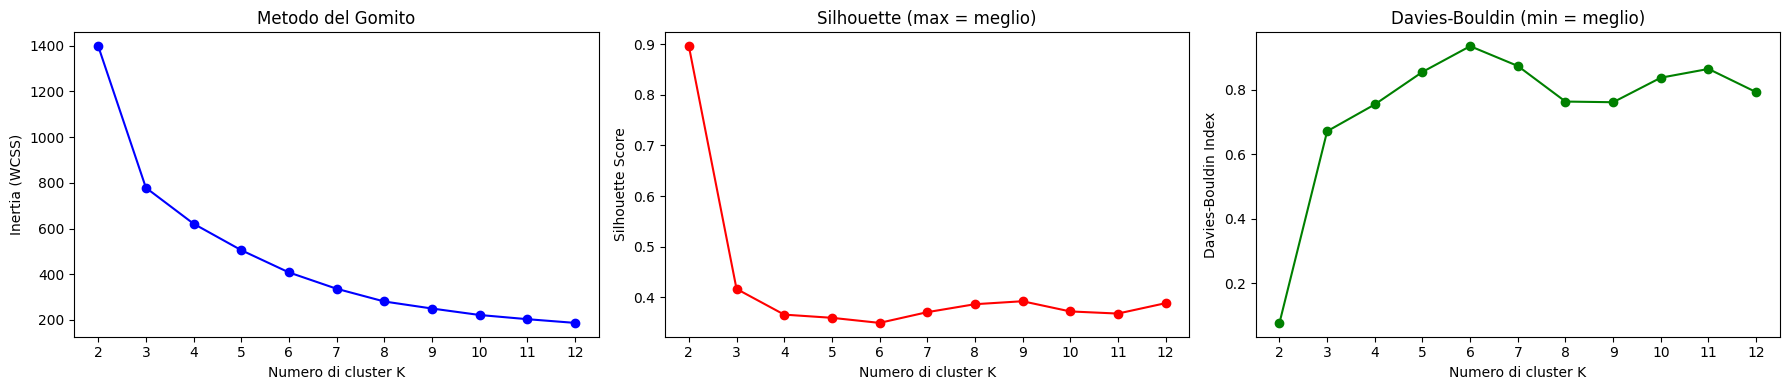

In [7]:
# 5.2.1 Esecuzione HDBSCAN
import hdbscan

print("Calcolo dei cluster con HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="manhattan"
)
hdbscan_labels = clusterer.fit_predict(embeddings_5d)
df["cluster_hdbscan"] = hdbscan_labels

n_clusters_hdb = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_hdb = list(hdbscan_labels).count(-1)

print(f"HDBSCAN ha individuato {n_clusters_hdb} cluster e ha classificato {n_noise_hdb} report come rumore (outlier).")

In [ ]:
print(df["cluster_hdbscan"].value_counts())

In [8]:
NUM_CLUSTERS = len(df['cluster_hdbscan'].unique())-1

for cluster_id in range(NUM_CLUSTERS):
    subset = df[df["cluster_hdbscan"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))

Calcolo dei cluster con HDBSCAN...
HDBSCAN ha individuato 4 cluster e ha classificato 121 report come rumore (outlier).


## 6. Interpretazione, Lemmatizzazione e Validazione dei Cluster

### 6.1 Clustering Finale K-Means

In [10]:
# 6.1.1 K-Means definitivo
K_SCELTO = 7 # Imposta manualmente qui il K desiderato (es. K_SCELTO = 5)

km_final = KMeans(n_clusters=K_SCELTO, random_state=42, n_init=10)
df["cluster_kmeans"] = km_final.fit_predict(embeddings_5d)

# Trova l'indice del report più vicino al centroide per ciascun cluster
indici_piu_vicini, _ = pairwise_distances_argmin_min(km_final.cluster_centers_, embeddings_5d)


=== CLUSTER 0 (91 documenti) ===
                      paese inizio_periodo fine_periodo
                El Salvador       Mar 2025     Feb 2026
                   Honduras       Mar 2025     Feb 2026
                 Mozambique       Jul 2016     Feb 2017
                  Guatemala       Mar 2025     Feb 2026
                 Madagascar       Jul 2019     Jun 2020
                 Mozambique       Apr 2024     Mar 2025
                     Malawi       Nov 2019     Mar 2020
                 Madagascar       Mar 2017     Sep 2017
                    Lesotho       Jul 2021     Mar 2022
                      Haiti       Apr 2014     Sep 2014
                      Haiti       Oct 2018     Jun 2019
                   Djibouti       Nov 2016     May 2017
                   Eswatini       Jun 2022     Mar 2023
                      Haiti       Oct 2017     Jun 2018
                    Lesotho       Dec 2018     Feb 2019
                 Madagascar       Mar 2018     Sep 2018
              

In [ ]:
# ============================================================
# STEP 3: ESPLORA I CLUSTER
# ============================================================
for cluster_id in range(K_SCELTO):
    subset = df[df["cluster_kmeans"] == cluster_id]
    print(f"\n=== CLUSTER {cluster_id} ({len(subset)} documenti) ===")
    print(subset[["paese", "inizio_periodo", "fine_periodo"]].to_string(index=False))

### 6.2 Analisi della Contingenza (Esclusione del Bias Geografico)

Per verificare se il clustering è guidato da driver semantici o se è semplicemente caduto in un bias geografico (raggruppando i report solo per Paese), calcoliamo:
1. **Tabella di Contingenza (Paese vs. Cluster)**: mostra quanti report di ciascun Paese cadono in ciascun cluster.
2. **Entropia Geografica del Cluster**: calcoliamo l'entropia della distribuzione dei Paesi per ciascun cluster. Valori di entropia più elevati indicano che il cluster aggrega report da molteplici Paesi differenti, confermando la bontà semantica del raggruppamento.

In [12]:
# 6.2.1 Calcolo Tabella di Contingenza ed Entropia per K-means
print("TABELLA DI CONTINGENZA (PAESE vs. CLUSTER K-MEANS):")
tabella_contingenza = pd.crosstab(df["paese"], df["cluster_kmeans"])
print(tabella_contingenza.to_string())

print(
    "\nENTROPIA GEOGRAFICA PER CIASCUN CLUSTER:\n"
    "(Valori alti = il cluster contiene molti paesi diversi, indicando coerenza semantica e basso bias geografico)"
)
for c_id in range(K_SCELTO):
    conteggio_paesi = df[df["cluster_kmeans"] == c_id]["paese"].value_counts()
    entropia_val = stats.entropy(conteggio_paesi)
    print(f"Cluster {c_id}: Entropia Geografica = {entropia_val:.2f} (Paesi unici: {len(conteggio_paesi)})")


=== CLUSTER 0 (53 documenti) ===
                      paese inizio_periodo fine_periodo
United Republic of Tanzania       Nov 2023     Oct 2024
                 Bangladesh       Aug 2013     Oct 2013
   Central African Republic       Apr 2015     Nov 2015
                     Uganda       Apr 2025     Mar 2026
                    Lesotho       Jul 2021     Mar 2022
   Central African Republic       Nov 2014     Mar 2015
United Republic of Tanzania       Feb 2026     Jan 2027
                     Zambia       Aug 2023     Mar 2024
                      Yemen       Apr 2013     Apr 2013
                      Sudan       Nov 2014     Dec 2014
                  Guatemala       Jul 2017     Jul 2017
                 Mozambique       Apr 2018     Sep 2018
   Central African Republic       Apr 2014     May 2014
                     Uganda       Apr 2023     Feb 2024
                Afghanistan       Sep 2014     Mar 2015
                   Pakistan       Oct 2014     Dec 2014
              

In [ ]:
# 6.2.2 Calcolo Tabella di Contingenza ed Entropia
print("TABELLA DI CONTINGENZA (PAESE vs. CLUSTER HDBSCAN):")
tabella_contingenza = pd.crosstab(df["paese"], df["cluster_hdbscan"])
print(tabella_contingenza.to_string())

print(
    "\nENTROPIA GEOGRAFICA PER CIASCUN CLUSTER:\n"
    "(Valori alti = il cluster contiene molti paesi diversi, indicando coerenza semantica e basso bias geografico)"
)
for c_id in range(K_SCELTO):
    conteggio_paesi = df[df["cluster_hdbscan"] == c_id]["paese"].value_counts()
    entropia_val = stats.entropy(conteggio_paesi)
    print(f"Cluster {c_id}: Entropia Geografica = {entropia_val:.2f} (Paesi unici: {len(conteggio_paesi)})")

### 6.3 Topic Modeling

Per ottenere parole chiave semanticamente pulite, definiamo una pipeline di tokenizzazione personalizzata con **lemmatizzazione (NLTK WordNet Lemmatizer)** che riconduce le forme flesse alla loro radice (es. *conflicts* e *conflict* diventano entrambi *conflict*).

Rimuoveremo anche:
- Le stop words inglesi classiche.
- I nomi di tutti i Paesi inclusi nel dataset (ricavati automaticamente per evitare che i cluster contengano riferimenti geografici come parole chiave).
- Termini generici ricorrenti nei report (es. *people*, *report*, *situation*).

In [ ]:
# 6.2.1 Inizializzazione lemmatizer NLTK e stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Ricava i nomi unici dei paesi (in minuscolo) dal dataset per escluderli dalle parole chiave
nomi_paesi = set(df["paese"].str.lower().unique())
stop_words.update(nomi_paesi)

# Aggiungiamo termini generici dei report per isolare solo i driver delle crisi
termini_generici = [
    "action", "acute", "acute_food", "affected", "affected_area", "affectedarea",
    "analysed", "analysis", "analyzed", "area", "classified", "compare",
    "compared", "country", "crisis", "current", "date", "district", "districts",
    "emergency", "estimated", "expected", "facing", "famine", "food",
    "food_insecurity", "high", "household", "households", "insecurity", "ipc",
    "key", "level", "likely", "million", "minimal", "number", "overall",
    "people", "percent", "period", "phase", "population", "population_figure",
    "populationfigure", "projected", "projection", "province", "provinces",
    "report", "results", "security", "several", "situation", "stressed",
    "total", "urgent"
]
stop_words.update(termini_generici)

# Funzione di tokenizzazione e lemmatizzazione per TfidfVectorizer
def tokenize_and_lemmatize(text):
    # Rimuove numeri e caratteri non alfabetici
    text_pulito = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text_pulito.lower())

    # Lemmatizza e filtra stop words e parole corte
    tokens_lemmatizzati = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return tokens_lemmatizzati



#### 6.3.1 Implementazione c-TF-IDF dalla libreria bertopic (per K-Means)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

def estrai_parole_chiave_bertopic(df: pd.DataFrame, cluster_col: str, top_n: int = 10) -> dict:
    """
    Estrae le parole chiave applicando l'aggregazione spaziale a livello di DataFrame
    e calcolando il c-TF-IDF tramite BERTopic.
    """
    # 1. Aggregazione spaziale: concateniamo tutti i report appartenenti allo stesso cluster
    class_docs = df.groupby(cluster_col)["report_anonimo"].apply(lambda testi: ' '.join(testi)).reset_index()

    # 2. Creazione matrice dei conteggi sui testi GIÀ AGGREGATI
    # Il numero di righe di X ora corrisponde al numero esatto di cluster, non di documenti
    vectorizer = CountVectorizer(analyzer=tokenize_and_lemmatize, max_features=1000)
    X = vectorizer.fit_transform(class_docs["report_anonimo"])

    # 3. Trasformazione c-TF-IDF
    # Nessun parametro 'y' necessario. X è già a livello di classe.
    ctfidf_transformer = ClassTfidfTransformer()
    ctfidf_matrix = ctfidf_transformer.fit_transform(X)

    # 4. Estrazione delle keyword
    terms = vectorizer.get_feature_names_out()
    keywords_per_cluster = {}

    # L'ordine delle righe nella matrice ctfidf_matrix corrisponde all'ordine del groupby
    for index, row in class_docs.iterrows():
        cluster_id = row[cluster_col]
        class_scores = ctfidf_matrix[index].toarray().flatten()

        # Ordinamento inverso per i punteggi più alti
        top_indices = class_scores.argsort()[::-1][:top_n]
        keywords_per_cluster[cluster_id] = [terms[i] for i in top_indices]

    return keywords_per_cluster

In [15]:
# Stampa pulita dei risultati K-Means
print(f"============================================================")
print(f"RISULTATI DEL CLUSTERING SEMANTICO CON BGE-M3 (K-MEANS)")
print(f"============================================================")


# Estrae 10 parole chiave per ogni cluster
dizionario_keywords = estrai_parole_chiave_bertopic(df, "cluster_kmeans", top_n=10)

# 2. ITERAZIONE
for c_id in df["cluster_kmeans"].unique():
    subset = df[df["cluster_kmeans"] == c_id]
    if len(subset) == 0:
        continue

    
    keywords_del_cluster = dizionario_keywords.get(c_id, [])

    # 4. STAMPA
    print(f"\n\n👉 CLUSTER {c_id} ({len(subset)} report)")
    print("-" * 60)
    print(f"📝 Driver Semantici Reali: {', '.join(keywords_del_cluster)}")


RISULTATI DEL CLUSTERING SEMANTICO CON BGE-M3 (K-MEANS)


👉 CLUSTER 0 (53 report)
------------------------------------------------------------
📝 Driver Semantici Reali: analysis, districts, levels, production, conditions, season, consumption, projected, access, prices
📌 Report Manifesto: Lesotho (May 2025 / Mar 2026)
📄 Estratto del Manifesto:
More than [POPULATION_FIGURE] people living in [AFFECTED_AREA] of [AFFECTED_AREA] (17 percent of the population analysed) have been experiencing high levels of acute food insecurity, classified as IPC Phase 3 or above (Crisis or worse) between May and September [DATE]. These people require urgent action to reduce food gaps, protect and restore livelihoods, and prevent acute malnutrition. Eight of ...


👉 CLUSTER 1 (6 report)
------------------------------------------------------------
📝 Driver Semantici Reali: thousand, set, february, worse, map, conditions, border, minimal, 52, seven
📌 Report Manifesto: Honduras (Nov 2018 / Apr 2019)
📄 Estratto d

#### 6.3.2 Esplorazione Qualitativa dei Cluster e dei Report Manifesto (K-Means)

In [17]:
def estrai_top_n_manifesti(df: pd.DataFrame, embeddings: np.ndarray, kmeans_model, cluster_col: str, cluster_id: int, top_n: int = 5) -> pd.DataFrame:
    """
    Estrae i documenti più vicini al centroide del cluster specificato
    utilizzando la matrice delle distanze nativa di scikit-learn.
    """
    # 1. Calcolo vettorializzato delle distanze di tutti i documenti da tutti i centroidi
    # L'output è una matrice (N_documenti, K_cluster)
    distanze_da_centroidi = kmeans_model.transform(embeddings)

    # 2. Isolamento della colonna relativa al centroide di nostro interesse
    distanze_cluster_specifico = distanze_da_centroidi[:, cluster_id]

    # 3. Ordinamento degli indici in base alla distanza crescente (più vicini al centroide)
    indici_ordinati = np.argsort(distanze_cluster_specifico)

    # 4. Estrazione dei primi N documenti, garantendo (tramite check di sicurezza)
    # che appartengano effettivamente all'etichetta del cluster
    indici_top = []
    for idx in indici_ordinati:
        if df.iloc[idx][cluster_col] == cluster_id:
            indici_top.append(idx)
        if len(indici_top) == top_n:
            break

    # 5. Ritorna il sotto-dataframe contenente i testi manifesto
    return df.iloc[indici_top]


# =====================================================================
# INTEGRAZIONE NEL CICLO DI OUTPUT
# =====================================================================
# Presuppone che:
# - 'matrice_embeddings' sia l'array numpy/tensore generato da BGE-M3
# - 'modello_kmeans' sia l'oggetto sklearn.cluster.KMeans già addestrato (es. modello_kmeans.fit(matrice_embeddings))

for c_id in df["cluster_kmeans"].unique():
    subset = df[df["cluster_kmeans"] == c_id]
    if len(subset) == 0:
        continue

    keywords_del_cluster = dizionario_keywords.get(c_id, [])

    print(f"\n\n👉 CLUSTER {c_id} ({len(subset)} report)")
    print("-" * 60)
    print(f"📝 Driver Semantici Reali: {', '.join(keywords_del_cluster)}")

    # Estrazione dei 5 documenti manifesto
    top_5_df = estrai_top_n_manifesti(df, embeddings_5d, km_final, "cluster_kmeans", c_id, top_n=5)

    print("📄 Top 5 Testi Manifesto (più vicini al centroide):")
    for i, (_, row) in enumerate(top_5_df.iterrows(), 1):
        estratto = row['testo_originale'].replace('\n', ' ')
        print(f"  {i}. [{row['paese']} - {row.get('periodo', 'N/D')}] {estratto}...")

#estraggo i 5 testi originali più vicini al centroide del proprio cluster e li passo a llm per verificare se i topic che identificano un cluster (ottenuti sempre tramite llm passanto le top10 parole) siano corretti

✅ Etichette K-Means assegnate con successo!
✅ Etichette HDBSCAN assegnate con successo!

RIEPILOGO DISTRIBUZIONE DEI REPORT PER CLUSTER

📊 Distribuzione HDBSCAN:
label_hdbscan
Crisi Complessa e Conflitto           189
Outlier / Dinamiche Miste (Rumore)    121
Shock Agricolo e Stagionale            91
Shock Pastorale e Carenza Idrica       57
Impatto Pandemico (COVID-19)           39

📊 Distribuzione K-Means:
label_kmeans
Violenza, Conflitti Armati e SfollaMento                  95
Eventi Climatici Estremi e Inflazione Alimentare          90
Shock Agricolo, Parassiti e Perdita Raccolti              70
Impatto Pandemico (COVID-19)                              62
Shock Pastorale, Carenza Idrica e Prezzi                  60
Crisi Integrate di Malnutrizione Infantile (AFI/AMN)      55
Vulnerabilità Strutturale e Consumi Alimentari            53
Cluster Anomalo (Tri-national Border / America Latina)     6
Crisi dei Settori Caffè e Grani di Base                    6


#### 6.3.3 Implementazione c-TF-IDF (cluster HDBSCAN)

In [18]:
# Stampa pulita dei risultati HDBSCAN
print(f"============================================================")
print(f"RISULTATI DEL CLUSTERING SEMANTICO CON BGE-M3 (HDBSCAN)")
print(f"============================================================")


# Estrae 10 parole chiave per ogni cluster
keywords_hdbscan = estrai_parole_chiave_bertopic(df, "cluster_hdbscan", top_n=10)

# 2. ITERAZIONE
for c_id in df["cluster_hdbscan"].unique()[1:]:
    subset = df[df["cluster_hdbscan"] == c_id]
    if len(subset) == 0:
        continue

    
    keywords_del_cluster = keywords_hdbscan.get(c_id, [])

    # 4. STAMPA
    print(f"\n\n👉 CLUSTER {c_id} ({len(subset)} report)")
    print("-" * 60)
    print(f"📝 Driver Semantici Reali: {', '.join(keywords_del_cluster)}")


,Unnamed: 0,nome_file,paese,periodo,inizio_periodo,fine_periodo,testo_originale,report_anonimo,x,y,cluster_hdbscan,cluster_kmeans,label_kmeans,label_hdbscan,continente
0,0,Gaza_Strip_Sep_2024_-_Apr_2025_KeyResults.txt,Gaza Strip,Sep 2024 / Apr 2025,Sep 2024,Apr 2025,"One year into the conflict, the risk of Famine...","One year into the conflict, the risk of Famine...",3.915741,-2.611245,2,6,"Violenza, Conflitti Armati e SfollaMento",Crisi Complessa e Conflitto,Asia
1,1,Afghanistan_Apr_2020_-_Nov_2020_KeyResults.txt,Afghanistan,Apr 2020 / Nov 2020,Apr 2020,Nov 2020,Food insecurity remains alarmingly high in Afg...,Food insecurity remains alarmingly high in [AF...,0.647212,0.075132,3,2,Impatto Pandemico (COVID-19),Impatto Pandemico (COVID-19),Asia
2,2,Afghanistan_Nov_2017_-_Feb_2018_KeyResults.txt,Afghanistan,Nov 2017 / Feb 2018,Nov 2017,Feb 2018,"During the 2017 post-harvest season, 33% of th...","During the [DATE] post-harvest season, 33% of ...",2.628111,0.121229,-1,2,Impatto Pandemico (COVID-19),Outlier / Dinamiche Miste (Rumore),Asia
3,3,South_Sudan_Sep_2018_-_Mar_2019_KeyResults.txt,South Sudan,Sep 2018 / Mar 2019,Sep 2018,Mar 2019,"Based on the September IPC analysis, it is exp...","Based on the September IPC analysis, it is exp...",2.370537,-1.452294,2,6,"Violenza, Conflitti Armati e SfollaMento",Crisi Complessa e Conflitto,Africa
4,4,Mozambique_Jun_2020_-_Sep_2020_KeyResults.txt,Mozambique,Jun 2020 / Sep 2020,Jun 2020,Sep 2020,The results of this Acute Food Insecurity pilo...,The results of this Acute Food Insecurity pilo...,0.416905,0.441027,3,2,Impatto Pandemico (COVID-19),Impatto Pandemico (COVID-19),Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,492,Haiti_Aug_2023_-_Jun_2024_KeyResults.txt,Haiti,Aug 2023 / Jun 2024,Aug 2023,Jun 2024,About 4.35 million people are experiencing hig...,About 4.35 million people are experiencing hig...,3.218394,-1.368603,2,6,"Violenza, Conflitti Armati e SfollaMento",Crisi Complessa e Conflitto,America
493,493,Djibouti_Mar_2022_-_Dec_2022_KeyResults.txt,Djibouti,Mar 2022 / Dec 2022,Mar 2022,Dec 2022,For the current analysis period of March throu...,For the current analysis period of March throu...,2.928871,0.260633,2,2,Impatto Pandemico (COVID-19),Crisi Complessa e Conflitto,Africa
494,494,Djibouti_May_2013_-_May_2013_KeyResults.txt,Djibouti,May 2013 / May 2013,May 2013,May 2013,Food availability in the Republic of Djibouti ...,Food availability in the [AFFECTED_AREA] is ma...,4.032279,3.469265,1,4,"Shock Pastorale, Carenza Idrica e Prezzi",Shock Pastorale e Carenza Idrica,Africa
495,495,Madagascar_Sep_2024_-_Aug_2025_KeyResults.txt,Madagascar,Sep 2024 / Aug 2025,Sep 2024,Aug 2025,"Between September and December 2024, around 1....","Between September and December [DATE], around ...",1.837947,-1.493744,2,8,Eventi Climatici Estremi e Inflazione Alimentare,Crisi Complessa e Conflitto,Africa


#### 6.3.5 Esplorazione Qualitativa dei Cluster e dei Report Manifesto (HDBSCAN)

In [20]:
from scipy.spatial.distance import cdist # Ensure cdist is available

def estrai_top_n_manifesti_for_hdbscan(df: pd.DataFrame, embeddings: np.ndarray, cluster_labels_series: pd.Series, cluster_id: int, top_n: int = 5) -> pd.DataFrame:
    """
    Estrae i documenti più vicini al "centro" di un cluster HDBSCAN.
    Calcola un centroide virtuale (media degli embedding dei documenti assegnati al cluster)
    e poi la distanza di ciascun documento del cluster da esso.
    """
    # Get the global indices of documents belonging to the current cluster
    global_cluster_indices = df[df[cluster_labels_series.name] == cluster_id].index.values

    if len(global_cluster_indices) == 0:
        return pd.DataFrame() # Return empty DataFrame if no documents in cluster

    # Get embeddings for the current cluster
    cluster_embeddings = embeddings[global_cluster_indices]

    # Calculate the centroid (mean) of these cluster embeddings
    cluster_centroid = np.mean(cluster_embeddings, axis=0).reshape(1, -1)

    # Calculate cosine distances from each document in the cluster to its centroid
    # The 'metric' should align with what UMAP used if possible, 'cosine' is often good for embeddings.
    distances_to_centroid = cdist(cluster_embeddings, cluster_centroid, metric='cosine').flatten()

    # Get the local indices that sort the distances
    sorted_local_indices = np.argsort(distances_to_centroid)

    # Get the top_n global indices
    top_n_global_indices = global_cluster_indices[sorted_local_indices[:top_n]]

    return df.loc[top_n_global_indices]

for c_id in df["cluster_hdbscan"].unique():

    subset = df[df["cluster_hdbscan"] == c_id]
    if (len(subset) == 0) or (c_id==-1):
        continue

    keywords_del_cluster = dizionario_keywords.get(c_id, [])

    print(f"\n\n👉 CLUSTER {c_id} ({len(subset)} report)")
    print("-" * 60)
    print(f"📝 Driver Semantici Reali: {', '.join(keywords_del_cluster)}")

    # Estrazione dei 5 documenti manifesto - NOW USING THE HDBSCAN-SPECIFIC FUNCTION
    top_5_df = estrai_top_n_manifesti_for_hdbscan(df, embeddings_5d, df["cluster_hdbscan"], c_id, top_n=5)

    print("📄 Top 5 Testi Manifesto (più vicini al centroide):")
    for i, (_, row) in enumerate(top_5_df.iterrows(), 1):
        estratto = row['testo_originale'].replace('\n', ' ')
        print(f"  {i}. [{row['paese']} - {row.get('periodo', 'N/D')}] {estratto}...")

#estraggo i 5 testi originali più vicini al centroide del proprio cluster e li passo a llm per verificare se i topic che identificano un cluster (ottenuti sempre tramite llm passanto le top10 parole) siano corretti

Grafico hdbscan salvato con successo in: ./mappa_cluster_hdbscan_interattiva.html


In [ ]:
# Mappatura semantica dei cluster basata sui driver TF-IDF emersi
hdbscan_cluster_labels = {
    -1: "Rumore di Fondo / Condizioni Generali",
    0: "Impatto El Niño e La Niña",
    1: "Produzione Agricola",
    2: "Malattie del Bestiame",
    3: "Stress Economico Generalizzato",
    4: "Impatto Pandemia COVID-19",
    5: "Shock Climatico Agricolo",
    6: "Inondazioni e Monsoni",
    7: "Malnutrizione Infantile",
    8: "Crisi Umanitaria da Conflitto",
    10: "Tendenze Macroeconomiche"
}

kmeans_cluster_labels = {
    0: "Malnutrizione Infantile",
    1: "Mappatura Territoriale Transfrontaliera",
    2: "Impatto Precipitazioni sui Raccolti",
    3: "Impatto Economico COVID-19",
    4: "Emergenza Rifugiati da Conflitto",
    5: "Vulnerabilità Idrica Agropastorale",
    6: "Inflazione Prezzi Agricoli"
}
# Assegnazione dei nomi nel DataFrame
if "cluster_kmeans" in df.columns:
    df["label_kmeans"] = df["cluster_kmeans"].map(kmeans_cluster_labels)
    print("✅ Etichette K-Means assegnate con successo!")

# Assegnazione etichette HDBSCAN (se la colonna 'cluster_hdbscan' esiste)
if "cluster_hdbscan" in df.columns:
    df["label_hdbscan"] = df["cluster_hdbscan"].map(hdbscan_cluster_labels)
    print("✅ Etichette HDBSCAN assegnate con successo!")

# Riepilogo finale della distribuzione
print("\n============================================================")
print("RIEPILOGO DISTRIBUZIONE DEI REPORT PER CLUSTER")
print("============================================================")

if "label_hdbscan" in df.columns:
    print("\n📊 Distribuzione HDBSCAN:")
    print(df["label_hdbscan"].value_counts().to_string())

if "label_kmeans" in df.columns:
    print("\n📊 Distribuzione K-Means:")
    print(df["label_kmeans"].value_counts().to_string())

## 7. Rappresentazione Grafica Interattiva (Plotly)

Creiamo uno scatter plot interattivo 2D proiettando le coordinate UMAP. Passando il puntatore sopra ciascun punto, verranno mostrati il Paese, il Periodo e le prime righe di anteprima del report.

In [ ]:
#mappatura paesi in macro regioni
paesi_continenti = {
    "Angola": "Africa",
    "Burundi": "Africa",
    "Central African Republic": "Africa",
    "Democratic Republic of the Congo": "Africa",
    "Djibouti": "Africa",
    "Eswatini": "Africa",
    "Ethiopia": "Africa",
    "Kenya": "Africa",
    "Lesotho": "Africa",
    "Madagascar": "Africa",
    "Malawi": "Africa",
    "Mozambique": "Africa",
    "Namibia": "Africa",
    "Somalia": "Africa",
    "South Africa": "Africa",
    "South Sudan": "Africa",
    "Sudan": "Africa",
    "Uganda": "Africa",
    "United Republic of Tanzania": "Africa",
    "Zambia": "Africa",
    "Zimbabwe": "Africa",
    "Afghanistan": "Asia",
    "Bangladesh": "Asia",
    "Cambodia": "Asia",
    "Gaza Strip": "Asia",
    "Lebanon": "Asia",
    "Pakistan": "Asia",
    "Tajikistan": "Asia",
    "Timor-Leste": "Asia",
    "Yemen": "Asia",
    "Dominican Republic": "America",
    "Ecuador": "America",
    "El Salvador": "America",
    "Guatemala": "America",
    "Haiti": "America",
    "Honduras": "America"
}

df["continente"] = df.paese.map(paesi_continenti)
df

In [ ]:
import plotly.graph_objects as go
# 7.1 Visualizzazione grafica interattiva
# Creiamo un'anteprima del testo per il tooltip (evitando ritorni a capo per un tooltip pulito)

simboli_continenti = {
    "Africa": "circle",
    "Asia": "square",
    "America": "diamond",
}
cluster_unici = df["label_kmeans"].dropna().unique().tolist()
palette_default = px.colors.qualitative.Plotly

# Creazione di un dizionario che lega ogni cluster a un colore di default in ordine
mappatura_dinamica = {
    label: palette_default[i % len(palette_default)]
    for i, label in enumerate(cluster_unici)
}
# =====================================================================
# 2. CREAZIONE DELLO SCATTER PLOT INTERATTIVO K-MEANS
# =====================================================================
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label_kmeans",
    symbol="continente",
    color_discrete_map=mappatura_dinamica,
    symbol_map=simboli_continenti,
    hover_data={
        "paese": True,
        "periodo": True,
        "continente": True,
        "label_kmeans": True,
        "x": False,
        "y": False
    },
    title=f"Clustering Semantico dei Report IPC (K-Means K={K_SCELTO} su UMAP 2D)",
    labels={
        "label_kmeans": "Driver Semantico",
        "continente": "Continente",
        "paese": "Paese",
        "periodo": "Periodo",
        "anteprima_testo": "Anteprima"
    },
    category_orders={"label_kmeans": cluster_unici, "continente": ["Africa", "Asia", "America"]},
    width=1150,
    height=750
)

fig.update_traces(
    showlegend=False,
    marker=dict(size=10, opacity=0.85, line=dict(width=0.5, color='DarkSlateGrey'))
)

# 3. RICOSTRUZIONE MANUALE DELLA LEGENDA (Dummy Traces)

# Legenda Colori (Cluster)
for label in cluster_unici:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=10, color=mappatura_dinamica[label], symbol='circle', line=dict(width=0.5, color='DarkSlateGrey')),
        name=label,
        legendgroup="Cluster",
        legendgrouptitle_text="Driver Semantico (Colore)",
        showlegend=True
    ))

# Legenda Forme (Continente)
for continente, simbolo in simboli_continenti.items():
    # Verifica che il continente esista effettivamente nei dati prima di aggiungerlo alla legenda
    if continente in df["continente"].unique():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=10, color='grey', symbol=simbolo, line=dict(width=0.5, color='DarkSlateGrey')),
            name=continente,
            legendgroup="Continente",
            legendgrouptitle_text="Continente (Forma)",
            showlegend=True
        ))

# 4. AGGIORNAMENTO DEL LAYOUT
fig.update_layout(
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False, title="Componente UMAP 1"),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False, title="Componente UMAP 2"),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#EAEAEA",
        borderwidth=1,
        tracegroupgap=15 # Spazio verticale tra i due gruppi di legenda
    )
)


# =====================================================================
# 3. SALVATAGGIO E RENDERING
# =====================================================================
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path_km = os.path.join(DRIVE_PATH, "mappa_cluster_kmeans_interattiva.html")
else:
    output_html_path_km = "mappa_cluster_kmeans_interattiva.html"

fig.write_html(output_html_path_km)
print(f"Grafico K-Means salvato con successo in: {output_html_path_km}")

# Rendering del grafico
fig.show(renderer="browser")

In [ ]:
import plotly.graph_objects as go
# 7.1 Visualizzazione grafica interattiva
# Creiamo un'anteprima del testo per il tooltip (evitando ritorni a capo per un tooltip pulito)

simboli_continenti = {
    "Africa": "circle",
    "Asia": "square",
    "America": "diamond",
}
cluster_unici = df["label_hdbscan"].dropna().unique().tolist()
palette_default = px.colors.qualitative.Plotly

# Creazione di un dizionario che lega ogni cluster a un colore di default in ordine
mappatura_dinamica = {
    label: palette_default[i % len(palette_default)]
    for i, label in enumerate(cluster_unici)
}
# =====================================================================
# 2. CREAZIONE DELLO SCATTER PLOT INTERATTIVO hdbscan
# =====================================================================
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label_hdbscan",
    symbol="continente",
    color_discrete_map=mappatura_dinamica,
    symbol_map=simboli_continenti,
    hover_data={
        "paese": True,
        "periodo": True,
        "continente": True,
        "label_hdbscan": True,
        "x": False,
        "y": False
    },
    title=f"Clustering Semantico dei Report IPC (hdbscan su UMAP 2D)",
    labels={
        "label_hdbscan": "Driver Semantico",
        "continente": "Continente",
        "paese": "Paese",
        "periodo": "Periodo",
        "anteprima_testo": "Anteprima"
    },
    category_orders={"label_hdbscan": cluster_unici, "continente": ["Africa", "Asia", "America"]},
    width=1150,
    height=750
)

fig.update_traces(
    showlegend=False,
    marker=dict(size=10, opacity=0.85, line=dict(width=0.5, color='DarkSlateGrey'))
)

# 3. RICOSTRUZIONE MANUALE DELLA LEGENDA (Dummy Traces)

# Legenda Colori (Cluster)
for label in cluster_unici:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=10, color=mappatura_dinamica[label], symbol='circle', line=dict(width=0.5, color='DarkSlateGrey')),
        name=label,
        legendgroup="Cluster",
        legendgrouptitle_text="Driver Semantico (Colore)",
        showlegend=True
    ))

# Legenda Forme (Continente)
for continente, simbolo in simboli_continenti.items():
    # Verifica che il continente esista effettivamente nei dati prima di aggiungerlo alla legenda
    if continente in df["continente"].unique():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(size=10, color='grey', symbol=simbolo, line=dict(width=0.5, color='DarkSlateGrey')),
            name=continente,
            legendgroup="Continente",
            legendgrouptitle_text="Continente (Forma)",
            showlegend=True
        ))

# 4. AGGIORNAMENTO DEL LAYOUT
fig.update_layout(
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False, title="Componente UMAP 1"),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False, title="Componente UMAP 2"),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#EAEAEA",
        borderwidth=1,
        tracegroupgap=15 # Spazio verticale tra i due gruppi di legenda
    )
)


# =====================================================================
# 3. SALVATAGGIO E RENDERING
# =====================================================================
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path_km = os.path.join(DRIVE_PATH, "mappa_cluster_hdbscan_interattiva.html")
else:
    output_html_path_km = "mappa_cluster_hdbscan_interattiva.html"

fig.write_html(output_html_path_km)
print(f"Grafico hdbscan salvato con successo in: {output_html_path_km}")

# Rendering del grafico
fig.show(renderer="browser")

In [ ]:
import altair as alt
import pandas as pd
import os

# 1. PARSING E ORDINAMENTO CRONOLOGICO
df['data_inizio'] = pd.to_datetime(df['periodo'].str.split(' / ').str[0], format='%b %Y', errors='coerce')
df = df.sort_values(by=["paese", "data_inizio"])

if "continente" not in df.columns:
    print("Errore critico: Colonna 'continente' mancante nel DataFrame.")

# Estrazione del dominio fisso per impedire il collasso dell'asse Y
domini_cluster = sorted(df['label_hdbscan'].unique().tolist())

# 2. DEFINIZIONE DEI PARAMETRI DI SELEZIONE
click_dissolvenza = alt.selection_point(
    fields=['paese'],
    on='click',
    empty=True,
    clear='dblclick'
)

click_filtro = alt.selection_point(
    fields=['paese'],
    on='click',
    empty=False,
    clear='dblclick'
)

# 3. CREAZIONE DELLO SCATTER PLOT
punti = alt.Chart(df).mark_point(
    filled=True,
    size=100,
    stroke='black',
    strokeWidth=0.5
).encode(
    x=alt.X('x:Q', title='Componente UMAP 1', scale=alt.Scale(zero=False)),
    y=alt.Y('y:Q', title='Componente UMAP 2', scale=alt.Scale(zero=False)),
    color=alt.Color('label_hdbscan:N', legend=alt.Legend(title="Driver Semantico")),
    shape=alt.Shape('continente:N', legend=alt.Legend(title="Continente")),
    opacity=alt.condition(click_dissolvenza, alt.value(0.9), alt.value(0.05)),
    tooltip=['paese:N', 'periodo:N', 'continente:N', 'label_hdbscan:N']
).add_params(
    click_dissolvenza,
    click_filtro
).properties(
    width=950,
    height=550,
    title="Clustering Semantico dei Report IPC (Clicca su un marker per isolare un paese)"
)

# 4. CREAZIONE DEL LINE CHART (Asse Y statico)

# Layer 1: Linea di connessione cronologica
linea_temporale = alt.Chart(df).mark_line(
    color='gray',
    strokeWidth=2
).encode(
    x=alt.X(
        'periodo:O',
        title='Periodo',
        sort=alt.EncodingSortField(field='data_inizio', order='ascending'),
        axis=alt.Axis(labelAngle=-45, labelOverlap=False)
    ),
    y=alt.Y(
        'label_hdbscan:N',
        title='Driver Semantico (Cluster)',
        # Il parametro scale con dominio fisso impedisce il ridimensionamento dell'asse
        scale=alt.Scale(domain=domini_cluster),
        axis=alt.Axis(orient='right', labelLimit=300)
    ),
    order=alt.Order('data_inizio:T', sort='ascending')
)

# Layer 2: Marker colorati sovrapposti
punti_temporali = alt.Chart(df).mark_point(
    filled=True,
    size=100,
    opacity=1
).encode(
    x=alt.X(
        'periodo:O',
        sort=alt.EncodingSortField(field='data_inizio', order='ascending')
    ),
    y=alt.Y(
        'label_hdbscan:N',
        scale=alt.Scale(domain=domini_cluster) # Allineamento del dominio anche per i punti
    ),
    color=alt.Color('label_hdbscan:N', legend=None),
    tooltip=['paese:N', 'periodo:N', 'label_hdbscan:N']
)

# Assemblaggio dei layer per il grafico inferiore
andamento_temporale = (linea_temporale + punti_temporali).transform_filter(
    click_filtro
).properties(
    width=950,
    height=250,
    title="Andamento Temporale (Evoluzione Cluster nel tempo per il paese selezionato)"
)

# 5. ASSEMBLAGGIO FINALE
grafico_finale = alt.vconcat(
    punti,
    andamento_temporale
).configure_view(
    strokeWidth=0
).configure(
    padding={"bottom": 80}
)

# 6. SALVATAGGIO E RENDERING
output_html_path_altair = "mappa_percorsi_altair_click_line_chart_temporalmente_accurato.html"
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path_altair = os.path.join(DRIVE_PATH, output_html_path_altair)

grafico_finale.save(output_html_path_altair)
print(f"Grafico Altair salvato in: {output_html_path_altair}")

alt.renderers.enable('html')
grafico_finale.show()

In [ ]:
import altair as alt
import pandas as pd
import os

# 1. PARSING E ORDINAMENTO CRONOLOGICO
df['data_inizio'] = pd.to_datetime(df['periodo'].str.split(' / ').str[0], format='%b %Y', errors='coerce')
df = df.sort_values(by=["paese", "data_inizio"])

if "continente" not in df.columns:
    print("Errore critico: Colonna 'continente' mancante nel DataFrame.")

# 2. DEFINIZIONE DEI PARAMETRI DI SELEZIONE
click_dissolvenza = alt.selection_point(
    fields=['paese'],
    on='click',
    empty=True,
    clear='dblclick'
)

click_filtro = alt.selection_point(
    fields=['paese'],
    on='click',
    empty=False,
    clear='dblclick'
)

# 3. CREAZIONE DELLO SCATTER PLOT (Grafico Superiore)
punti = alt.Chart(df).mark_point(
    filled=True,
    size=100,
    stroke='black',
    strokeWidth=0.5
).encode(
    x=alt.X('x:Q', title='Componente UMAP 1', scale=alt.Scale(zero=False)),
    y=alt.Y('y:Q', title='Componente UMAP 2', scale=alt.Scale(zero=False)),
    color=alt.Color('label_hdbscan:N', legend=alt.Legend(title="Driver Semantico")),
    shape=alt.Shape('continente:N', legend=alt.Legend(title="Continente")),
    opacity=alt.condition(click_dissolvenza, alt.value(0.9), alt.value(0.05)),
    tooltip=['paese:N', 'periodo:N', 'continente:N', 'label_hdbscan:N']
).add_params(
    click_dissolvenza,
    click_filtro
).properties(
    width=950,
    height=550,
    title="Clustering Semantico dei Report IPC (Clicca su un marker per isolare un paese)"
)

# 4. CREAZIONE DELLA HEATMAP MONOLINEA (Grafico Inferiore)
heatmap_temporale = alt.Chart(df).mark_rect(
    stroke='white', # Aggiunge un bordo bianco tra le celle per separarle visivamente
    strokeWidth=1
).encode(
    x=alt.X(
        'periodo:O',
        title='Periodo',
        sort=alt.EncodingSortField(field='data_inizio', order='ascending'),
        axis=alt.Axis(labelAngle=-45, labelOverlap=False)
    ),
    y=alt.Y(
        'paese:N',
        title='Paese Selezionato',
        axis=alt.Axis(orient='right') # Orientamento standard a sinistra
    ),
    color=alt.Color(
        'label_hdbscan:N',
        legend=None # Legenda soppressa, eredita quella dello scatter plot
    ),
    tooltip=['paese:N', 'periodo:N', 'label_hdbscan:N']
).transform_filter(
    click_filtro
).properties(
    width=950,
    height=60, # Altezza compressa per ospitare una singola riga
    title="Cronologia Cluster (Heatmap per il paese selezionato)"
)

# 5. ASSEMBLAGGIO FINALE
grafico_finale = alt.vconcat(
    punti,
    heatmap_temporale
).configure_view(
    strokeWidth=0
).configure(
    padding={"bottom": 80} # Padding mantenuto per non tagliare l'asse X ruotato
)

# 6. SALVATAGGIO E RENDERING
output_html_path_altair = "mappa_percorsi_altair_click_heatmap.html"
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path_altair = os.path.join(DRIVE_PATH, output_html_path_altair)

grafico_finale.save(output_html_path_altair)
print(f"Grafico Altair salvato in: {output_html_path_altair}")

alt.renderers.enable('html')
grafico_finale.show()

In [ ]:
import altair as alt
from vega_datasets import data
import pandas as pd
import os

# 1. PARSING, ORDINAMENTO CRONOLOGICO E INIEZIONE COORDINATE SPAZIALI
df['data_inizio'] = pd.to_datetime(df['periodo'].str.split(' / ').str[0], format='%b %Y', errors='coerce')
df = df.sort_values(by=["paese", "data_inizio"])

# Dizionario statico dei centroidi per risolvere la mancanza di coordinate nel DataFrame
centroidi = {
    "Angola": [-11.2027, 17.8739], "Burundi": [-3.3731, 29.9189],
    "Central African Republic": [6.6111, 20.9394], "Democratic Republic of the Congo": [-4.0383, 21.7587],
    "Djibouti": [11.8251, 42.5903], "Eswatini": [-26.5225, 31.4659],
    "Ethiopia": [9.1450, 40.4897], "Kenya": [-0.0236, 37.9062],
    "Lesotho": [-29.6100, 28.2336], "Madagascar": [-18.7669, 46.8691],
    "Malawi": [-13.2543, 34.3015], "Mozambique": [-18.6657, 35.5296],
    "Namibia": [-22.9576, 18.4904], "Somalia": [5.1521, 46.1996],
    "South Africa": [-30.5595, 22.9375], "South Sudan": [6.8770, 31.3070],
    "Sudan": [12.8628, 30.2176], "Uganda": [1.3733, 32.2903],
    "United Republic of Tanzania": [-6.3690, 34.8888], "Zambia": [-13.1339, 27.8493],
    "Zimbabwe": [-19.0154, 29.1549], "Afghanistan": [33.9391, 67.7100],
    "Bangladesh": [23.6850, 90.3563], "Cambodia": [12.5657, 104.9910],
    "Gaza Strip": [31.3547, 34.3088], "Lebanon": [33.8547, 35.8623],
    "Pakistan": [30.3753, 69.3451], "Tajikistan": [38.8610, 71.2761],
    "Timor-Leste": [-8.8742, 125.7275], "Yemen": [15.5527, 48.5164],
    "Dominican Republic": [18.7357, -70.1627], "Ecuador": [-1.8312, -78.1834],
    "El Salvador": [13.7942, -88.8965], "Guatemala": [15.7835, -90.2308],
    "Haiti": [18.9712, -72.2852], "Honduras": [15.2000, -86.2419]
}

# Mappatura delle coordinate sul DataFrame corrente
df['lat'] = df['paese'].map(lambda x: centroidi.get(x, [None, None])[0])
df['lon'] = df['paese'].map(lambda x: centroidi.get(x, [None, None])[1])

# Rimozione di eventuali record che non possiedono coordinate per evitare crash silenziosi
df = df.dropna(subset=['lat', 'lon'])

if "continente" not in df.columns:
    print("Errore critico: Colonna 'continente' mancante nel DataFrame.")

# 2. DEFINIZIONE DEI PARAMETRI DI SELEZIONE
click_dissolvenza = alt.selection_point(
    fields=['paese'],
    on='click',
    empty=True,
    clear='dblclick'
)

click_filtro = alt.selection_point(
    fields=['paese'],
    on='click',
    empty=False,
    clear='dblclick'
)

# Selezione per catturare il periodo e il cluster durante l'hover sulla heatmap
click_heatmap_mappa = alt.selection_point(
    fields=['periodo', 'label_hdbscan'],
    on='click',
    empty=False
)
# 3. CREAZIONE DELLO SCATTER PLOT (Grafico Superiore)
punti = alt.Chart(df).mark_point(
    filled=True,
    size=100,
    stroke='black',
    strokeWidth=0.5
).encode(
    x=alt.X('x:Q', title='Componente UMAP 1', scale=alt.Scale(zero=False)),
    y=alt.Y('y:Q', title='Componente UMAP 2', scale=alt.Scale(zero=False)),
    color=alt.Color('label_hdbscan:N', legend=alt.Legend(title="Driver Semantico")),
    shape=alt.Shape('continente:N', legend=alt.Legend(title="Continente")),
    opacity=alt.condition(click_dissolvenza, alt.value(0.9), alt.value(0.05)),
    tooltip=['paese:N', 'periodo:N', 'continente:N', 'label_hdbscan:N']
).add_params(
    click_dissolvenza,
    click_filtro
).properties(
    width=950,
    height=550,
    title="Clustering Semantico dei Report IPC (Clicca su un marker per isolare un paese)"
)

# 4. CREAZIONE DELLA HEATMAP MONOLINEA (Grafico Inferiore - Sinistra)
heatmap_temporale = alt.Chart(df).mark_rect(
    stroke='white',
    strokeWidth=1
).encode(
    x=alt.X(
        'periodo:O',
        title='Periodo',
        sort=alt.EncodingSortField(field='data_inizio', order='ascending'),
        axis=alt.Axis(labelAngle=-45, labelOverlap=False)
    ),
    y=alt.Y(
        'paese:N',
        title='Paese Selezionato',
        axis=alt.Axis(orient='right')
    ),
    color=alt.Color(
        'label_hdbscan:N',
        legend=None
    ),
    tooltip=['paese:N', 'periodo:N', 'label_hdbscan:N']
).add_params(
    click_heatmap_mappa # Il nuovo parametro di selezione su click iniettato qui
).transform_filter(
    click_filtro
).properties(
    width=500,
    height=60,
    title="Cronologia Cluster (Clicca per mappare i paesi simili)"
)

# 5. CREAZIONE DELLA MAPPA GEOGRAFICA DINAMICA A CENTROIDI (Grafico Inferiore - Destra)
world = alt.topo_feature(data.world_110m.url, 'countries')

sfondo_mappa = alt.Chart(world).mark_geoshape(
    fill='#f0f0f0',
    stroke='white',
    strokeWidth=0.5
).project('equirectangular')

punti_mappa = alt.Chart(df).mark_circle(
    size=150,
    stroke='black',
    strokeWidth=1
).encode(
    longitude='lon:Q',
    latitude='lat:Q',
    color=alt.Color('label_hdbscan:N', legend=None),
    tooltip=['paese:N', 'periodo:N', 'label_hdbscan:N']
).transform_filter(
    click_heatmap_mappa # La mappa ora reagisce unicamente al clic sulla heatmap
)

mappa_dinamica = (sfondo_mappa + punti_mappa).properties(
    width=400,
    height=250,
    title="Paesi Affetti (Stesso Cluster nel Periodo Selezionato)"
)

# 6. ASSEMBLAGGIO FINALE
blocco_inferiore = alt.hconcat(
    heatmap_temporale,
    mappa_dinamica
).resolve_scale(
    color='shared'
)

grafico_finale = alt.vconcat(
    punti,
    blocco_inferiore
).configure_view(
    strokeWidth=0
).configure(
    padding={"bottom": 80}
)

# 7. SALVATAGGIO E RENDERING
output_html_path_altair = "mappa_percorsi_altair_click_heatmap_geo.html"
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path_altair = os.path.join(DRIVE_PATH, output_html_path_altair)

grafico_finale.save(output_html_path_altair)
print(f"Grafico Altair salvato in: {output_html_path_altair}")

alt.renderers.enable('html')
grafico_finale.show()

In [ ]:
# 7.1 Visualizzazione grafica interattiva

# Convertiamo la categoria del cluster in stringa per usare colori distinti
ordine_legenda = [
    "Shock Agricolo e Stagionale",
    "Shock Pastorale e Carenza Idrica",
    "Crisi Complessa e Conflitto",
    "Impatto Pandemico (COVID-19)",
    "Outlier / Dinamiche Miste (Rumore)"
]

# Palette di colori personalizzata (grigio discreto per il rumore/outlier)
colori_custom = {
    "Shock Agricolo e Stagionale": "#1f77b4",       # Blu
    "Shock Pastorale e Carenza Idrica": "#2ca02c",   # Verde
    "Crisi Complessa e Conflitto": "#d62728",       # Rosso
    "Impatto Pandemico (COVID-19)": "#ff7f0e",      # Arancione
    "Outlier / Dinamiche Miste (Rumore)": "#7f7f7f" # Grigio
}


# =====================================================================
# 2. CREAZIONE DELLO SCATTER PLOT INTERATTIVO CON PLOTLY EXPRESS
# =====================================================================
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label_hdbscan",
    color_discrete_map=colori_custom,
    hover_data={
        "paese": True,
        "periodo": True,
        "label_hdbscan": True,
        "x": False,
        "y": False
    },
    title="Clustering Semantico dei Report IPC (HDBSCAN su UMAP 2D)",
    labels={
        "tema_hdbscan": "Driver Semantico",
        "paese": "Paese",
        "periodo": "Periodo"
    },
    category_orders={"label_hdbscan": ordine_legenda},
    width=1150,
    height=750
)

# Miglioramento stilistico
fig.update_traces(
    marker=dict(size=8, opacity=0.85, line=dict(width=0.5, color='DarkSlateGrey'))
)

fig.update_layout(
    legend_title_text="Driver di Crisi",
    plot_bgcolor="#F8F9FA",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False, title="Componente UMAP 1"),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False, title="Componente UMAP 2"),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        bgcolor="rgba(255, 255, 255, 0.8)"
    )
)

# =====================================================================
# 3. SALVATAGGIO E RENDERING
# =====================================================================
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path = os.path.join(DRIVE_PATH, "mappa_cluster_interattiva.html")
else:
    output_html_path = "mappa_cluster_interattiva.html"

fig.write_html(output_html_path)
print(f"Grafico salvato con successo in: {output_html_path}")

# Rendering del grafico
fig.show(renderer="browser")

In [ ]:
import pycountry


# 1. Definizione della funzione di conversione
def get_iso3(name):
    manual_map = {
        "Gaza Strip": "PSE",
        "South Sudan": "SSD",
        "Kosovo": "XKX"
    }
    if name in manual_map:
        return manual_map[name]
    try:
        country = pycountry.countries.search_fuzzy(name)[0]
        return country.alpha_3
    except:
        return None


# 2. Creazione della colonna mancante
df["iso_a3"] = df["paese"].apply(get_iso3)

# 3. Verifica rapida
if df["iso_a3"].isnull().sum() > 0:
    print(f"Attenzione: {df['iso_a3'].isnull().sum()} paesi non trovati.")
else:
    print("Conversione completata con successo.")
# Isola e stampa i nomi che non hanno trovato corrispondenza
paesi_mancanti = df[df["iso_a3"].isnull()]["paese"].unique()

print(f"Paesi non trovati ({len(paesi_mancanti)}):")
for p in paesi_mancanti:
    print(f"- '{p}'")


def get_iso3(name):
    # Mapping manuale aggiornato
    manual_map = {
        "Gaza Strip": "PSE",
        "South Sudan": "SSD",
        "Kosovo": "XKX",
        "Democratic Republic of the Congo": "COD"  # Aggiunta necessaria
    }

    if name in manual_map:
        return manual_map[name]

    try:
        # Ricerca fuzzy del nome paese
        country = pycountry.countries.search_fuzzy(name)[0]
        return country.alpha_3
    except:
        return None


# Riesegui l'applicazione
df["iso_a3"] = df["paese"].apply(get_iso3)
# Filtra e visualizza tutti i paesi che non hanno ancora un codice ISO-3
mancanti = df[df["iso_a3"].isnull()]["paese"].unique()
print(f"Paesi ancora da mappare ({len(mancanti)}): {mancanti}")


In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

fig = go.Figure()

# =====================================================================
# 2. TRACCE KMEANS
# =====================================================================
unique_km = sorted(df["cluster_kmeans"].unique())
km_traces_all = []

for c in unique_km:
    subset = df[df["cluster_kmeans"] == c]
    label_tema = kmeans_cluster_labels.get(c, f"Cluster {c}")

    # Testo formattato che compare al passaggio del mouse sui paesi
    hover_info = [
        f"<b>Paese:</b> {row.get('paese', 'N/A')}<br>"
        f"<b>Periodo:</b> {row.get('periodo', 'N/A')}<br>"
        f"<b>Tema:</b> {label_tema}"
        for _, row in subset.iterrows()
    ]

    trace = go.Choropleth(
        locations=subset["iso_a3"],
        locationmode="ISO-3",
        z=[1] * len(subset),
        colorscale="Reds",
        showscale=False,
        name=f"KM: {label_tema}",
        hovertext=hover_info,
        hoverinfo="text",
        visible=False
    )
    fig.add_trace(trace)
    km_traces_all.append(len(fig.data) - 1)

# Traccia "KMeans - Tutti"
hover_km_all = [
    f"<b>Paese:</b> {row.get('paese', 'N/A')}<br>"
    f"<b>Tema:</b> {row['label_kmeans']}"
    for _, row in df.iterrows()
]

fig.add_trace(go.Choropleth(
    locations=df["iso_a3"],
    locationmode="ISO-3",
    z=df["cluster_kmeans"],
    colorscale="Reds",
    showscale=False,
    name="KMeans - Tutti",
    hovertext=hover_km_all,
    hoverinfo="text",
    visible=True
))
km_all_idx = len(fig.data) - 1


# =====================================================================
# 3. TRACCE HDBSCAN
# =====================================================================
unique_hdb = sorted([c for c in df["cluster_hdbscan"].unique() if c != -1])
hdb_traces_all = []

for c in unique_hdb:
    subset = df[df["cluster_hdbscan"] == c]
    label_tema = hdbscan_cluster_labels.get(c, f"Cluster {c}")

    hover_info = [
        f"<b>Paese:</b> {row.get('paese', 'N/A')}<br>"
        f"<b>Periodo:</b> {row.get('periodo', 'N/A')}<br>"
        f"<b>Tema:</b> {label_tema}"
        for _, row in subset.iterrows()
    ]

    trace = go.Choropleth(
        locations=subset["iso_a3"],
        locationmode="ISO-3",
        z=[1] * len(subset),
        colorscale="Greens",
        showscale=False,
        name=f"HDB: {label_tema}",
        hovertext=hover_info,
        hoverinfo="text",
        visible=False
    )
    fig.add_trace(trace)
    hdb_traces_all.append(len(fig.data) - 1)

# Traccia "HDBSCAN - Tutti" (Esclusi gli outlier -1)
subset_hdb_valid = df[df["cluster_hdbscan"] != -1]
hover_hdb_all = [
    f"<b>Paese:</b> {row.get('paese', 'N/A')}<br>"
    f"<b>Tema:</b> {row['label_hdbscan']}"
    for _, row in subset_hdb_valid.iterrows()
]

fig.add_trace(go.Choropleth(
    locations=subset_hdb_valid["iso_a3"],
    locationmode="ISO-3",
    z=subset_hdb_valid["cluster_hdbscan"],
    colorscale="Greens",
    showscale=False,
    name="HDBSCAN - Tutti",
    hovertext=hover_hdb_all,
    hoverinfo="text",
    visible=False
))
hdb_all_idx = len(fig.data) - 1


# =====================================================================
# 4. MENU A TENDINA CON I NOMI DEI TEMI
# =====================================================================
buttons = []

# Voci Menu per KMeans
buttons.append(
    dict(
        label="🔴 KMeans - Tutti i cluster",
        method="update",
        args=[{"visible": [i == km_all_idx for i in range(len(fig.data))]}]
    )
)
for i, c in zip(km_traces_all, unique_km):
    label_tema = kmeans_cluster_labels.get(c, f"Cluster {c}")
    buttons.append(
        dict(
            label=f"KMeans: {label_tema}",
            method="update",
            args=[{"visible": [idx == i for idx in range(len(fig.data))]}]
        )
    )

# Voci Menu per HDBSCAN
buttons.append(
    dict(
        label="🟢 HDBSCAN - Tutti i cluster",
        method="update",
        args=[{"visible": [i == hdb_all_idx for i in range(len(fig.data))]}]
    )
)
for i, c in zip(hdb_traces_all, unique_hdb):
    label_tema = hdbscan_cluster_labels.get(c, f"Cluster {c}")
    buttons.append(
        dict(
            label=f"HDBSCAN: {label_tema}",
            method="update",
            args=[{"visible": [idx == i for idx in range(len(fig.data))]}]
        )
    )


# =====================================================================
# 5. LAYOUT E MOSTRA MAPPA
# =====================================================================
fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.01,
        y=1.15,
        xanchor="left",
        yanchor="top"
    )],
    geo=dict(
        projection_type='natural earth',
        showland=True,
        landcolor="#f4f4f4",
        countrycolor="#d3d3d3"
    ),
    title="Visualizzazione Comparativa: Distribuzione Geografica dei Temi di Crisi",
    margin={"r": 0, "t": 80, "l": 0, "b": 0}
)

fig.show(renderer="browser")

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
import itertools
import os

# =====================================================================
# 1. PARSING DELLE DATE E DEFINIZIONE DELL'ORIZZONTE TEMPORALE
# =====================================================================
df[['str_inizio', 'str_fine']] = df['periodo'].str.split(' / ', expand=True, n=1)
df['data_inizio'] = pd.to_datetime(df['str_inizio'], format='%b %Y', errors='coerce')
df['data_fine'] = pd.to_datetime(df['str_fine'], format='%b %Y', errors='coerce')
df['data_fine'] = df['data_fine'].fillna(df['data_inizio'])

# Calcolo del range temporale globale (dal primissimo report all'ultimo)
mese_min = df['data_inizio'].min()
mese_max = df['data_fine'].max()

# Genera una lista continua di tutti i mesi nell'orizzonte temporale
mesi_globali = pd.date_range(start=mese_min, end=mese_max, freq='MS').strftime('%Y-%m')

# Estrai l'elenco univoco di tutti i paesi presenti nel dataset
paesi_unici = df[['iso_a3', 'paese']].drop_duplicates()


# =====================================================================
# 2. CREAZIONE DELLA MATRICE DI STATO CONTINUA E FORWARD-FILL
# =====================================================================
# Prodotto cartesiano: genera una griglia dove OGNI paese esiste in OGNI mese
griglia = pd.DataFrame(list(itertools.product(paesi_unici['iso_a3'], mesi_globali)), columns=['iso_a3', 'mese_attivo'])
griglia = griglia.merge(paesi_unici, on='iso_a3')

# Prepara i dati reali focalizzandosi solo sul momento in cui il cluster "cambia" (data_inizio)
dati_cambiamento = df.copy()
dati_cambiamento['mese_attivo'] = dati_cambiamento['data_inizio'].dt.strftime('%Y-%m')
# Se un paese ha più report nello stesso mese, mantieni l'ultimo per evitare duplicati spaziali
dati_cambiamento = dati_cambiamento.sort_values('data_inizio').drop_duplicates(subset=['iso_a3', 'mese_attivo'], keep='last')

# Fonde la griglia vuota con i dati reali
df_continuo = griglia.merge(dati_cambiamento[['iso_a3', 'mese_attivo', 'label_kmeans', 'periodo']], on=['iso_a3', 'mese_attivo'], how='left')

# PROPAGAZIONE DELLO STATO:
# ffill() mantiene il colore del paese finché non arriva un nuovo report.
# bfill() forza il colore iniziale all'indietro, in modo che il paese sia colorato fin dal primo frame (anche prima del suo primo report ufficiale).
df_continuo['label_kmeans'] = df_continuo.groupby('iso_a3')['label_kmeans'].ffill().bfill()
df_continuo['periodo'] = df_continuo.groupby('iso_a3')['periodo'].ffill().bfill()

# Ordinamento finale rigoroso per garantire la coerenza dei frame di Plotly
df_continuo = df_continuo.sort_values(by=['mese_attivo', 'iso_a3'])


# =====================================================================
# 3. DEFINIZIONE COLORI GLOBALI
# =====================================================================
colori_custom_km = {
    "Vulnerabilità Strutturale e Consumi Alimentari": "#1f77b4",
    "Cluster Anomalo (Tri-national Border / America Latina)": "#8c564b",
    "Impatto Pandemico (COVID-19)": "#ff7f0e",
    "Shock Agricolo, Parassiti e Perdita Raccolti": "#2ca02c",
    "Shock Pastorale, Carenza Idrica e Prezzi": "#e377c2",
    "Crisi Integrate di Malnutrizione Infantile (AFI/AMN)": "#9467bd",
    "Violenza, Conflitti Armati e SfollaMento": "#d62728",
    "Crisi dei Settori Caffè e Grani di Base": "#7f7f7f",
    "Eventi Climatici Estremi e Inflazione Alimentare": "#17becf"
}


# =====================================================================
# 4. CREAZIONE MAPPA COROPLETICA ANIMATA
# =====================================================================
fig = px.choropleth(
    df_continuo,
    locations="iso_a3",
    locationmode="ISO-3",
    color="label_kmeans",
    hover_name="paese",
    hover_data={
        "periodo": True,
        "label_kmeans": True,
        "iso_a3": False,
        "mese_attivo": False
    },
    animation_frame="mese_attivo",
    color_discrete_map=colori_custom_km,
    projection="natural earth",
    title="Evoluzione Continua dei Driver di Crisi per Paese",
    labels={"label_kmeans": "Driver Semantico"}
)

fig.update_layout(
    geo=dict(
        showland=True,
        landcolor="#f4f4f4",
        countrycolor="#d3d3d3",
        showcountries=True
    ),
    margin={"r": 0, "t": 80, "l": 0, "b": 0}
)

if len(fig.layout.updatemenus) > 0:
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 800


# =====================================================================
# 5. SALVATAGGIO E RENDERING
# =====================================================================
output_html_path_mappa = "mappa_temporale_stato_continuo.html"
if 'DRIVE_PATH' in locals() or 'DRIVE_PATH' in globals():
    output_html_path_mappa = os.path.join(DRIVE_PATH, output_html_path_mappa)

fig.write_html(output_html_path_mappa)
print(f"Mappa animata salvata in: {output_html_path_mappa}")

fig.show(renderer="browser")

### 8. Valutazione modelli

In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- FILTRO PER HDBSCAN (Escludiamo gli outlier -1 dalle metriche di distanza) ---
df_filtered = df[df["cluster_hdbscan"] != -1]
embeddings_filtered = embeddings_5d[df["cluster_hdbscan"] != -1]

# --- CALCOLO METRICHE K-MEANS ---
km_sil = silhouette_score(embeddings_5d, df["cluster_kmeans"])
km_ch = calinski_harabasz_score(embeddings_5d, df["cluster_kmeans"])
km_db = davies_bouldin_score(embeddings_5d, df["cluster_kmeans"])

# --- CALCOLO METRICHE HDBSCAN ---
hdb_sil = silhouette_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_ch = calinski_harabasz_score(embeddings_filtered, df_filtered["cluster_hdbscan"])
hdb_db = davies_bouldin_score(embeddings_filtered, df_filtered["cluster_hdbscan"])

# --- COSTRUZIONE TABELLA DI CONFRONTO ---
confronto_data = {
    "Metrica": [
        "Numero di Cluster trovati",
        "Percentuale Rumore / Outliers",
        "Silhouette Score (Più alto = meglio)",
        "Calinski-Harabasz Index (Più alto = meglio)",
        "Davies-Bouldin Index (Più basso = meglio)"
    ],
    "K-Means": [
        df["cluster_kmeans"].nunique(),
        "0.0% (Forza tutti i punti)",
        f"{km_sil:.3f}",
        f"{km_ch:.1f}",
        f"{km_db:.3f}"
    ],
    "HDBSCAN": [
        df_filtered["cluster_hdbscan"].nunique(),
        f"{(df['cluster_hdbscan'] == -1).sum() / len(df) * 100:.1f}%",
        f"{hdb_sil:.3f}",
        f"{hdb_ch:.1f}",
        f"{hdb_db:.3f}"
    ]
}

df_confronto = pd.DataFrame(confronto_data)
print("\n=== TABELLA COMPARATIVA DEL CLUSTERING A 5D ===")
display(df_confronto)

In [ ]:
# 1. DEFINIZIONE DELLE GRIGLIE (Popolate correttamente per il tuo dataset)
grid_min_cluster = [5, 8, 10, 15]
grid_min_samples = [1, 2, 3, 5]
grid_metrics = ['euclidean', 'manhattan']

risultati = []

print("Esecuzione dell'ottimizzazione in corso...")

for m_cluster in grid_min_cluster:
    for m_samples in grid_min_samples:
        for metrica in grid_metrics:

            # CORREZIONE: gen_min_span_tree=True è obbligatorio per calcolare la stabilità
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=m_cluster,
                min_samples=m_samples,
                metric=metrica,
                gen_min_span_tree=True
            )
            labels = clusterer.fit_predict(embeddings_5d)

            # Calcola il numero di cluster (escludendo il rumore -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # Calcola la percentuale di rumore
            percentuale_rumore = (labels == -1).sum() / len(labels) * 100

            # Calcola le metriche solo se ci sono almeno 2 cluster reali
            if n_clusters >= 2 and percentuale_rumore < 90:
                mask = labels != -1
                sil_score = silhouette_score(embeddings_5d[mask], labels[mask])

                # Ora questo attributo non fallirà più
                dbcv_approx = clusterer.relative_validity_
            else:
                sil_score = np.nan
                dbcv_approx = np.nan

            risultati.append({
                "min_cluster_size": m_cluster,
                "min_samples": m_samples,
                "metric": metrica,
                "Num_Cluster": n_clusters,
                "Perc_Rumore_%": round(percentuale_rumore, 1),
                "Silhouette_Pura": round(sil_score, 3) if pd.notnull(sil_score) else np.nan,
                "Stabilita_Media": round(dbcv_approx, 3) if pd.notnull(dbcv_approx) else np.nan
            })

# Converte in DataFrame e ordina per Silhouette più alta
df_tuning = pd.DataFrame(risultati).dropna()
df_tuning = df_tuning.sort_values(by="Silhouette_Pura", ascending=False).reset_index(drop=True)

print("\n=== TOP 10 CONFIGURAZIONI MIGLIORI ===")
display(df_tuning.head(50))

### Confronto Diretto tra K-Means e HDBSCAN
Calcoliamo due metriche fondamentali per valutare la concordanza tra i partizionamenti generati dai due algoritmi:
1. **Adjusted Rand Index (ARI)**: misura la similarità tra i due assegnamenti ignorando le permutazioni. Varia da -1 a 1 (1 = cluster identici).
2. **Normalized Mutual Information (NMI)**: misura l'informazione reciproca normalizzata, utile per quantificare quanta informazione del primo clustering si ritrova nel secondo. Varia da 0 a 1.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Filtriamo eventualmente gli outlier di HDBSCAN se vogliamo confrontare solo le assegnazioni valide
# In questo caso teniamo tutti i dati, compresi i -1 di hdbscan (che verranno visti come un cluster a sé)
ari_score = adjusted_rand_score(df['cluster_kmeans'], df['cluster_hdbscan'])
nmi_score = normalized_mutual_info_score(df['cluster_kmeans'], df['cluster_hdbscan'])

print("============================================================")
print("CONFRONTO K-MEANS vs HDBSCAN")
print("============================================================")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi_score:.4f}")
print("\n* Valori vicini a 1 indicano una forte sovrapposizione tra i due algoritmi.")
print("* Valori vicini a 0 indicano partizionamenti indipendenti/differenti.")

In [ ]:
df["embeddings"] = list(embeddings)

In [ ]:
df = df.rename(columns={"embeddings": "embeddings_densi"})

In [ ]:
df

In [ ]:
df.to_csv("clustering_report_ipc_embeddings_densi_descrizione_clusters.csv", index=False)